# Fourier Transform in Python: Signal Processing & Transformations

This notebook explores the **Fourier Transform** and its practical applications in signal processing using Python. We will cover:

- The mathematical intuition behind the Fourier Transform
- Discrete Fourier Transform (DFT) and Fast Fourier Transform (FFT)
- Analyzing simple and complex signals
- Spectral leakage, windowing, and the Gibbs phenomenon
- Filtering noise in the frequency domain
- Time-frequency analysis with the Short-Time Fourier Transform (STFT)
- The Convolution Theorem

**Requirements:** `numpy`, `matplotlib`, `scipy`


In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq, fftshift
from scipy.signal import stft, windows
import warnings
warnings.filterwarnings('ignore')

# Set global plotting style
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10


## 1. Mathematical Foundation

The **Continuous Fourier Transform** of a signal $x(t)$ is:

$$X(f) = \int_{-\infty}^{\infty} x(t) e^{-j 2\pi f t} dt$$

In digital signal processing, we work with sampled data, so we use the **Discrete Fourier Transform (DFT)**:

$$X[k] = \sum_{n=0}^{N-1} x[n] e^{-j 2\pi k n / N}$$

The **Fast Fourier Transform (FFT)** is an efficient algorithm to compute the DFT with complexity $O(N \log N)$ instead of $O(N^2)$.

Key concepts:
- **Sampling Rate ($f_s$):** Number of samples per second (Hz)
- **Nyquist Frequency:** $f_s / 2$ — the maximum frequency we can resolve
- **Frequency Bins:** The FFT returns complex values for $N$ frequency bins spaced by $f_s / N$
- 

## 2. Example: Pure Sine Wave

Let's start with a simple sine wave and examine its frequency content.

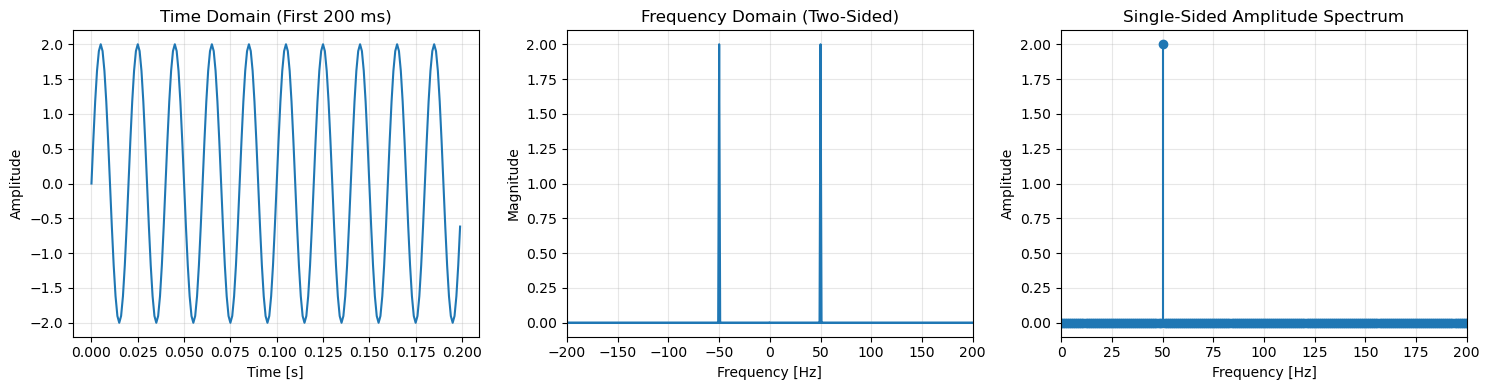

Peak frequency detected: 50.0 Hz
Detected amplitude: 2.00


In [49]:
# Parameters
fs = 1000           # Sampling frequency (Hz)
T = 1.0             # Duration (seconds)
t = np.linspace(0, T, int(fs * T), endpoint=False)

# Signal: 50 Hz sine wave
f_signal = 50
amplitude = 2.0
signal = amplitude * np.sin(2 * np.pi * f_signal * t)

# Compute FFT
N = len(signal)
yf = fft(signal)
xf = fftfreq(N, 1/fs)

# Plot time domain
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(t[:200], signal[:200])
axes[0].set_title('Time Domain (First 200 ms)')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

# Plot frequency domain (two-sided)
axes[1].plot(xf, np.abs(yf) / N * 2)
axes[1].set_title('Frequency Domain (Two-Sided)')
axes[1].set_xlabel('Frequency [Hz]')
axes[1].set_ylabel('Magnitude')
axes[1].set_xlim(-200, 200)
axes[1].grid(True, alpha=0.3)

# Plot single-sided spectrum
yf_single = 2.0/N * np.abs(yf[:N//2])
xf_single = xf[:N//2]
axes[2].stem(xf_single, yf_single, basefmt=' ')
axes[2].set_title('Single-Sided Amplitude Spectrum')
axes[2].set_xlabel('Frequency [Hz]')
axes[2].set_ylabel('Amplitude')
axes[2].set_xlim(0, 200)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Peak frequency detected: {xf_single[np.argmax(yf_single)]:.1f} Hz")
print(f"Detected amplitude: {np.max(yf_single):.2f}")


## 3. Example: Multi-Frequency Signal

Real-world signals contain multiple frequency components. Here we combine a 50 Hz sine wave with a 120 Hz cosine wave and add some DC offset.


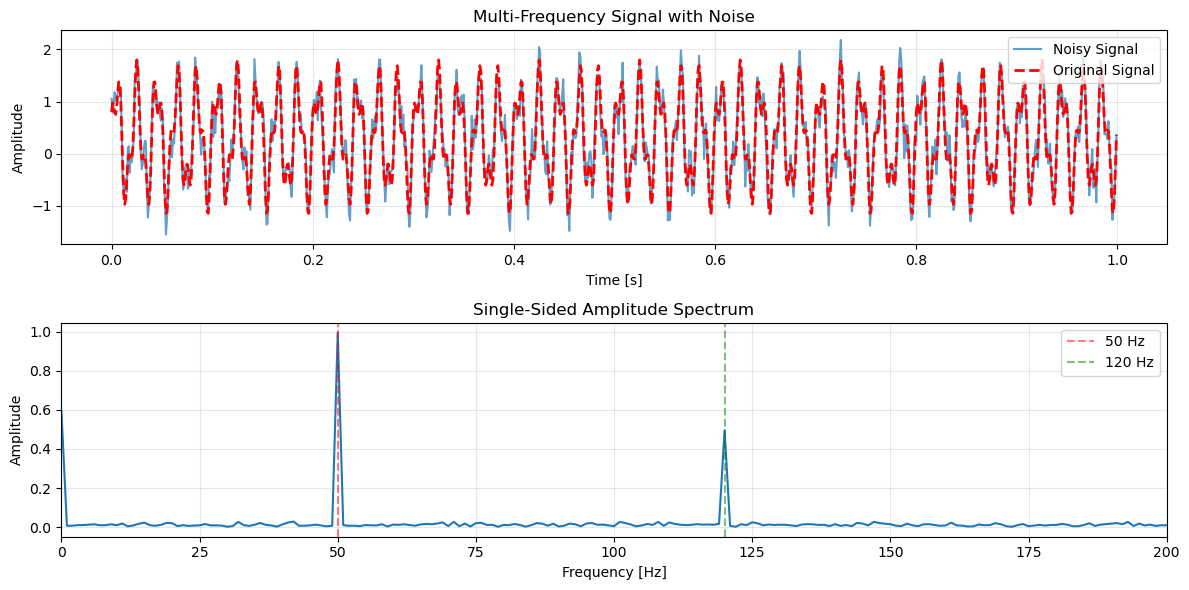

In [50]:
# Multi-component signal
f1, f2 = 50, 120
A1, A2 = 1.0, 0.5
dc_offset = 0.3

signal_multi = dc_offset + A1 * np.sin(2 * np.pi * f1 * t) + A2 * np.cos(2 * np.pi * f2 * t)

# Add some random noise
noise = 0.2 * np.random.randn(len(t))
signal_noisy = signal_multi + noise

# FFT
yf_multi = fft(signal_noisy)
xf = fftfreq(N, 1/fs)
yf_single = 2.0/N * np.abs(yf_multi[:N//2])
xf_single = xf[:N//2]

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Time domain
axes[0].plot(t, signal_noisy, alpha=0.7, label='Noisy Signal')
axes[0].plot(t, signal_multi, 'r--', linewidth=2, label='Original Signal')
axes[0].set_title('Multi-Frequency Signal with Noise')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Amplitude')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Frequency domain
axes[1].plot(xf_single, yf_single, linewidth=1.5)
axes[1].axvline(f1, color='r', linestyle='--', alpha=0.5, label=f'{f1} Hz')
axes[1].axvline(f2, color='g', linestyle='--', alpha=0.5, label=f'{f2} Hz')
axes[1].set_title('Single-Sided Amplitude Spectrum')
axes[1].set_xlabel('Frequency [Hz]')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlim(0, 200)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Example: Square Wave & Gibbs Phenomenon

A square wave can be represented as a sum of odd harmonics:

$$x(t) = \frac{4}{\pi} \sum_{k=1,3,5...}^{\infty} \frac{1}{k} \sin(2\pi k f_0 t)$$

We will synthesize a square wave by adding harmonics and observe the **Gibbs phenomenon** — ringing artifacts near discontinuities.


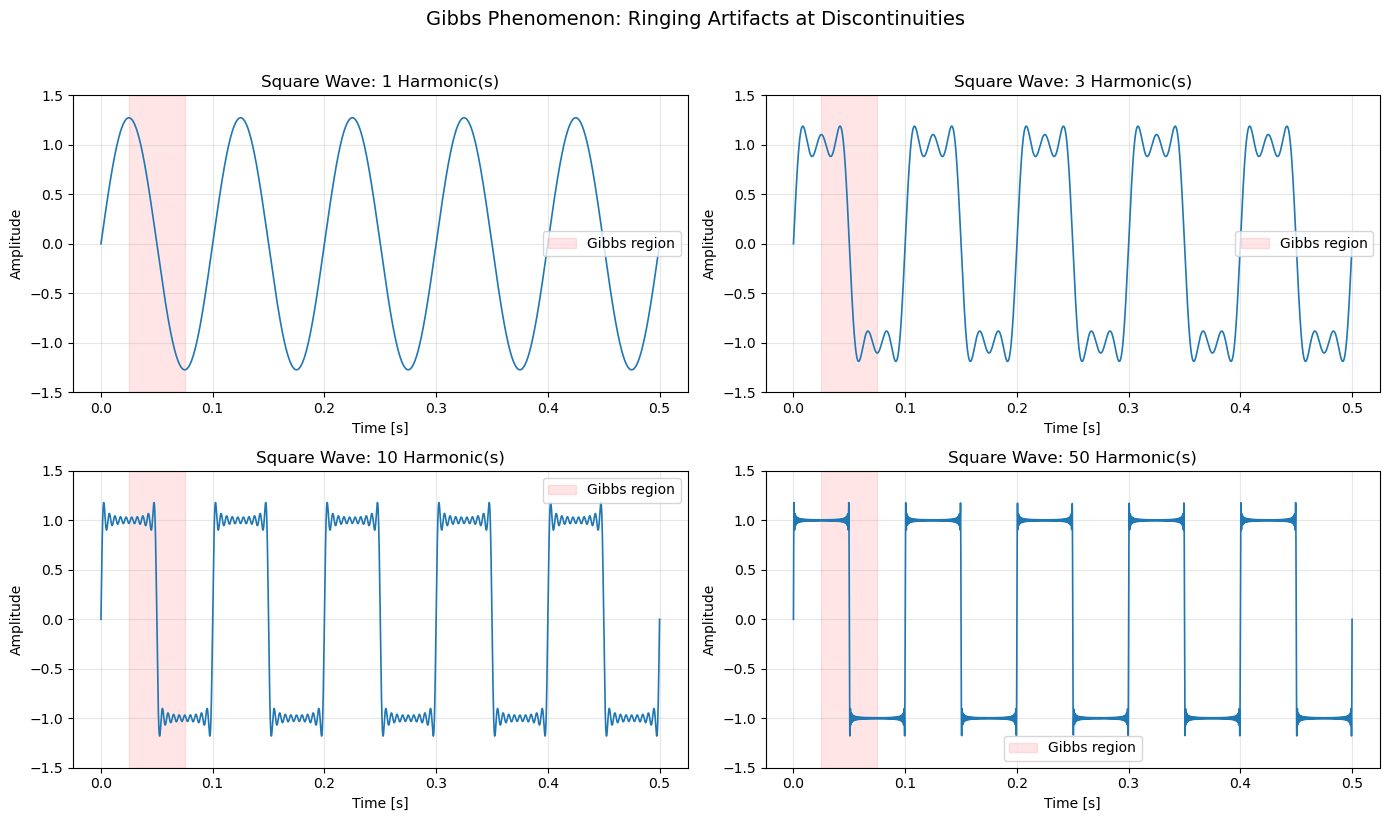

In [51]:
def synthesize_square(t, f0, n_harmonics):
    """Synthesize square wave from odd harmonics."""
    result = np.zeros_like(t)
    for k in range(1, 2*n_harmonics, 2):  # odd numbers: 1, 3, 5, ...
        result += (4 / np.pi) * (1 / k) * np.sin(2 * np.pi * k * f0 * t)
    return result

f0 = 10  # Fundamental frequency
t_long = np.linspace(0, 0.5, 5000)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

harmonics_list = [1, 3, 10, 50]
for idx, n_harm in enumerate(harmonics_list):
    ax = axes[idx // 2, idx % 2]
    sq = synthesize_square(t_long, f0, n_harm)
    ax.plot(t_long, sq, linewidth=1.2)
    ax.set_title(f'Square Wave: {n_harm} Harmonic(s)')
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Amplitude')
    ax.set_ylim(-1.5, 1.5)
    ax.grid(True, alpha=0.3)
    
    # Highlight Gibbs phenomenon region
    ax.axvspan(0.025, 0.075, alpha=0.1, color='red', label='Gibbs region')
    ax.legend()

plt.suptitle('Gibbs Phenomenon: Ringing Artifacts at Discontinuities', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 5. Example: Spectral Leakage & Windowing

When the signal frequency does not fall exactly on an FFT bin (i.e., the signal is not periodic in the observation window), **spectral leakage** occurs. Windowing reduces this effect.

Common windows:
- **Rectangular** (no window): sharp main lobe, high side lobes
- **Hanning**: good general-purpose window
- **Hamming**: similar to Hanning, different side lobe behavior
- **Blackman**: very low side lobes, wider main lobe
- 

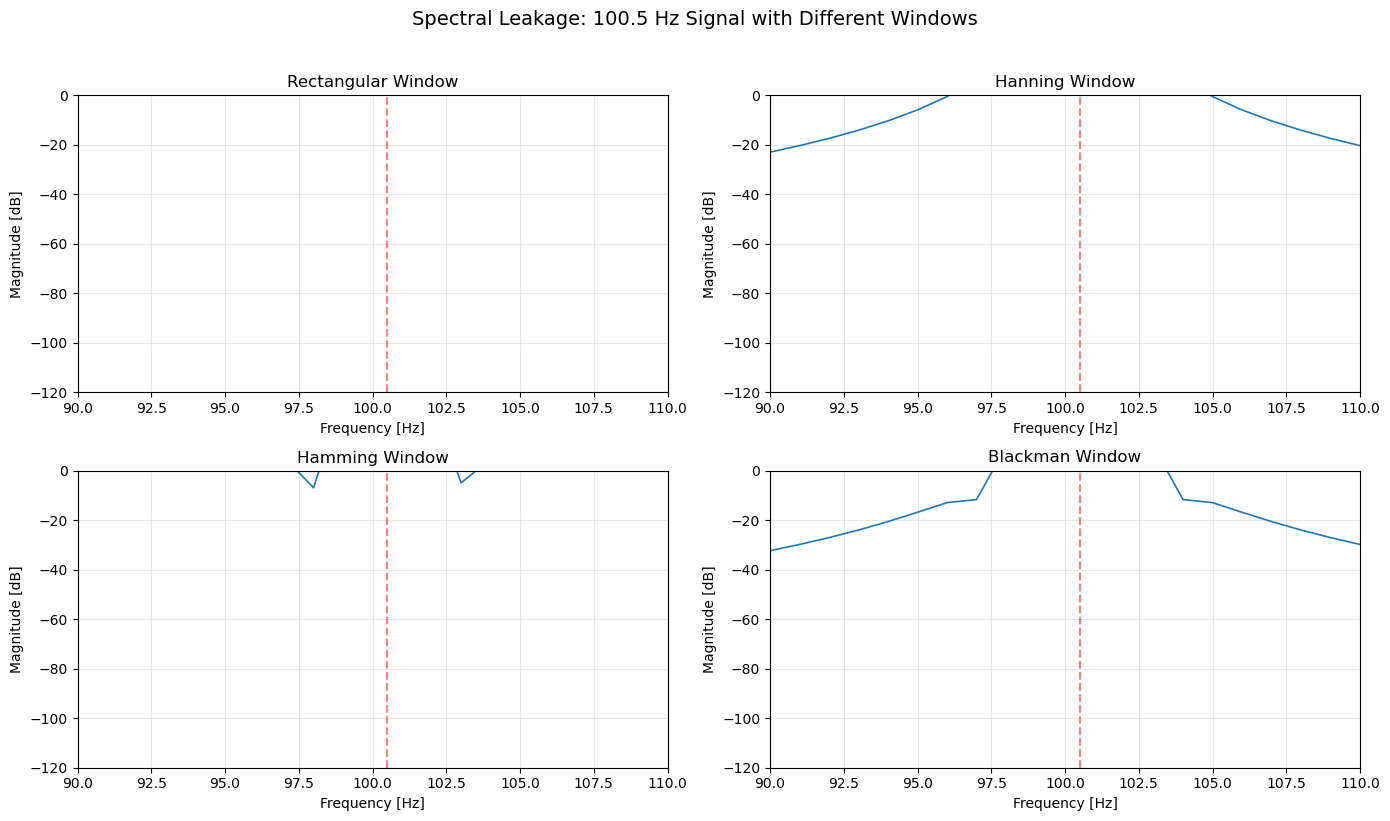

In [52]:
# Signal with non-integer number of cycles (causes leakage)
fs = 1024
N = 1024
t_win = np.arange(N) / fs
f_leak = 100.5  # Not an integer multiple of fs/N = 1 Hz
signal_leak = np.sin(2 * np.pi * f_leak * t_win)

windows_dict = {
    'Rectangular': windows.boxcar(N),
    'Hanning': windows.hann(N),
    'Hamming': windows.hamming(N),
    'Blackman': windows.blackman(N)
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, (name, win) in enumerate(windows_dict.items()):
    windowed = signal_leak * win
    yf = fft(windowed)
    xf = fftfreq(N, 1/fs)
    yf_mag = 20 * np.log10(np.abs(yf[:N//2]) + 1e-12)
    xf_pos = xf[:N//2]
    
    axes[idx].plot(xf_pos, yf_mag, linewidth=1.2)
    axes[idx].set_title(f'{name} Window')
    axes[idx].set_xlabel('Frequency [Hz]')
    axes[idx].set_ylabel('Magnitude [dB]')
    axes[idx].set_xlim(90, 110)
    axes[idx].set_ylim(-120, 0)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axvline(f_leak, color='r', linestyle='--', alpha=0.5)

plt.suptitle('Spectral Leakage: 100.5 Hz Signal with Different Windows', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 6. Example: Frequency Domain Filtering (Low-Pass Filter)

We can filter a signal by manipulating its FFT:
1. Transform the signal to the frequency domain
2. Zero out unwanted frequencies
3. Transform back to the time domain (IFFT)

This demonstrates a simple ideal low-pass filter.


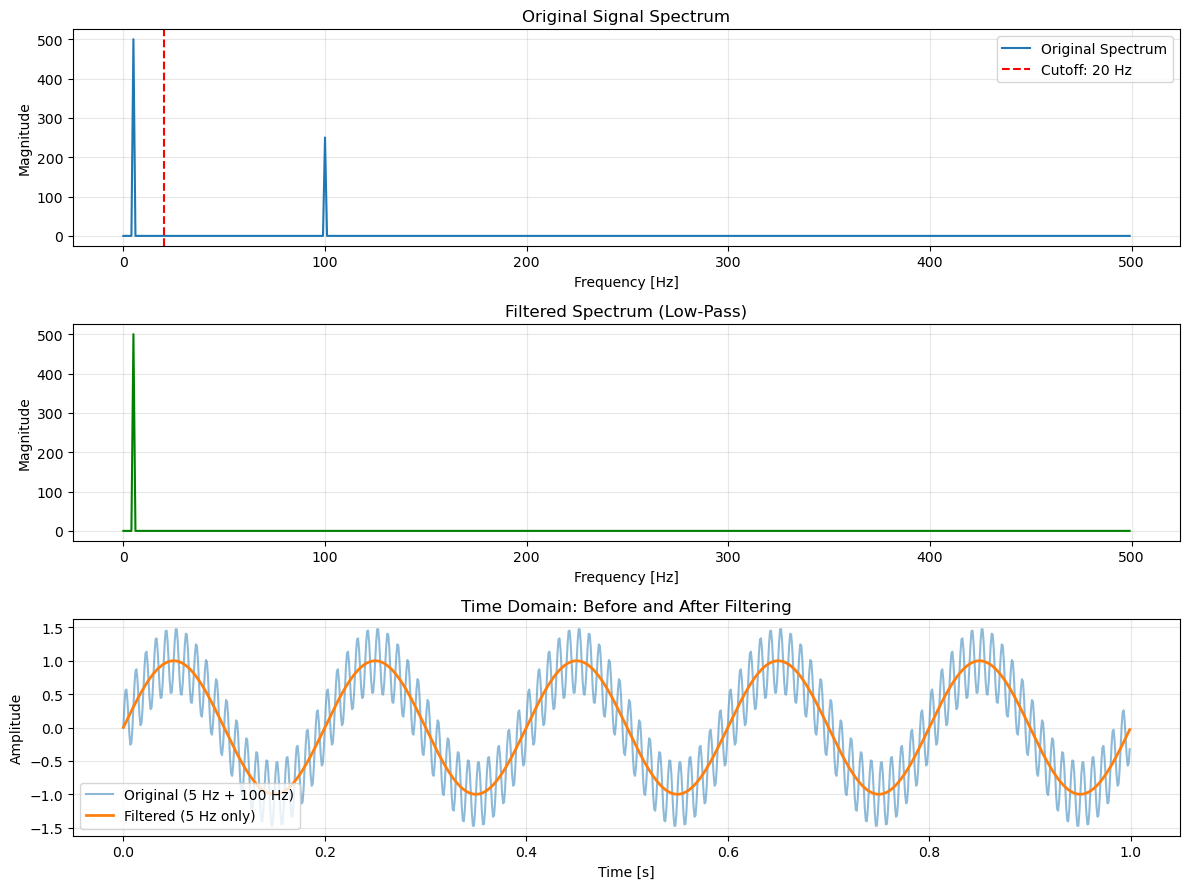

In [53]:
# Create a signal with low and high frequency components
fs = 1000
t_filt = np.linspace(0, 1, fs, endpoint=False)
signal_low = np.sin(2 * np.pi * 5 * t_filt)      # 5 Hz
signal_high = 0.5 * np.sin(2 * np.pi * 100 * t_filt)  # 100 Hz
signal_combined = signal_low + signal_high

# FFT
yf = fft(signal_combined)
xf = fftfreq(len(t_filt), 1/fs)

# Create low-pass filter mask (cutoff at 20 Hz)
cutoff = 20
filter_mask = np.abs(xf) <= cutoff
yf_filtered = yf * filter_mask

# IFFT to get filtered signal
signal_filtered = np.real(ifft(yf_filtered))

fig, axes = plt.subplots(3, 1, figsize=(12, 9))

# Original signal spectrum
axes[0].plot(xf[:fs//2], np.abs(yf[:fs//2]), label='Original Spectrum')
axes[0].axvline(cutoff, color='r', linestyle='--', label=f'Cutoff: {cutoff} Hz')
axes[0].set_title('Original Signal Spectrum')
axes[0].set_xlabel('Frequency [Hz]')
axes[0].set_ylabel('Magnitude')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Filtered spectrum
axes[1].plot(xf[:fs//2], np.abs(yf_filtered[:fs//2]), color='green')
axes[1].set_title('Filtered Spectrum (Low-Pass)')
axes[1].set_xlabel('Frequency [Hz]')
axes[1].set_ylabel('Magnitude')
axes[1].grid(True, alpha=0.3)

# Time domain comparison
axes[2].plot(t_filt, signal_combined, alpha=0.5, label='Original (5 Hz + 100 Hz)')
axes[2].plot(t_filt, signal_filtered, linewidth=2, label='Filtered (5 Hz only)')
axes[2].set_title('Time Domain: Before and After Filtering')
axes[2].set_xlabel('Time [s]')
axes[2].set_ylabel('Amplitude')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Example: Short-Time Fourier Transform (STFT) & Spectrogram

The FFT gives us frequency content but loses time information. The **STFT** divides the signal into overlapping windows and computes the FFT for each, producing a time-frequency representation called a **spectrogram**.

This is essential for analyzing non-stationary signals (signals whose frequency content changes over time).


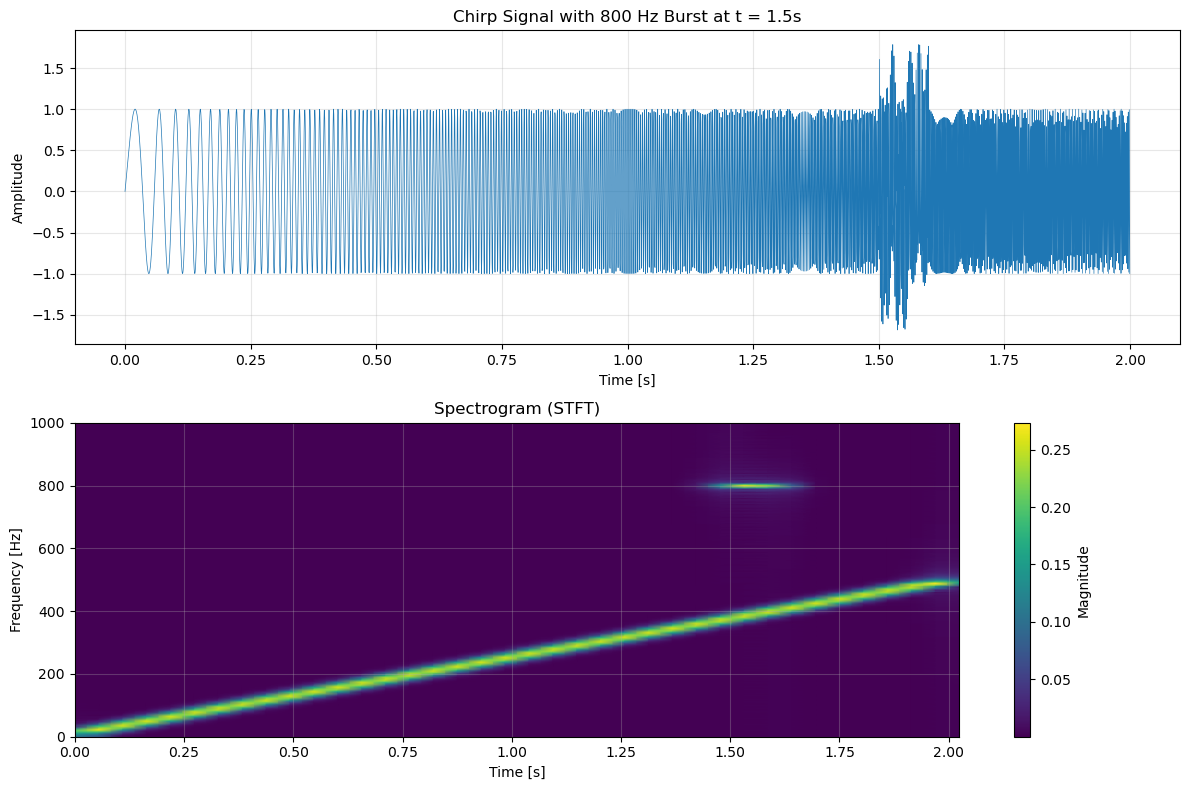

In [54]:
# Create a chirp signal (frequency increases over time)
fs = 2048
t_chirp = np.linspace(0, 2, 2 * fs, endpoint=False)
# Frequency sweeps from 10 Hz to 500 Hz
f0, f1 = 10, 500
signal_chirp = np.sin(2 * np.pi * (f0 * t_chirp + (f1 - f0) * t_chirp**2 / (2 * 2)))

# Add a brief high-frequency burst at t = 1.5s
burst_start, burst_end = int(1.5 * fs), int(1.6 * fs)
signal_chirp[burst_start:burst_end] += 0.8 * np.sin(2 * np.pi * 800 * t_chirp[burst_start:burst_end])

# Compute STFT
f_stft, t_stft, Zxx = stft(signal_chirp, fs=fs, nperseg=512, noverlap=400)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Time domain
axes[0].plot(t_chirp, signal_chirp, linewidth=0.5)
axes[0].set_title('Chirp Signal with 800 Hz Burst at t = 1.5s')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

# Spectrogram
im = axes[1].pcolormesh(t_stft, f_stft, np.abs(Zxx), shading='gouraud', cmap='viridis')
axes[1].set_title('Spectrogram (STFT)')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Frequency [Hz]')
axes[1].set_ylim(0, 1000)
fig.colorbar(im, ax=axes[1], label='Magnitude')

plt.tight_layout()
plt.show()


## 8. Example: The Convolution Theorem

The Convolution Theorem states that convolution in the time domain equals multiplication in the frequency domain:

$$\mathcal{F}\{x(t) * h(t)\} = X(f) \cdot H(f)$$

We verify this by comparing direct convolution with the FFT-based approach.


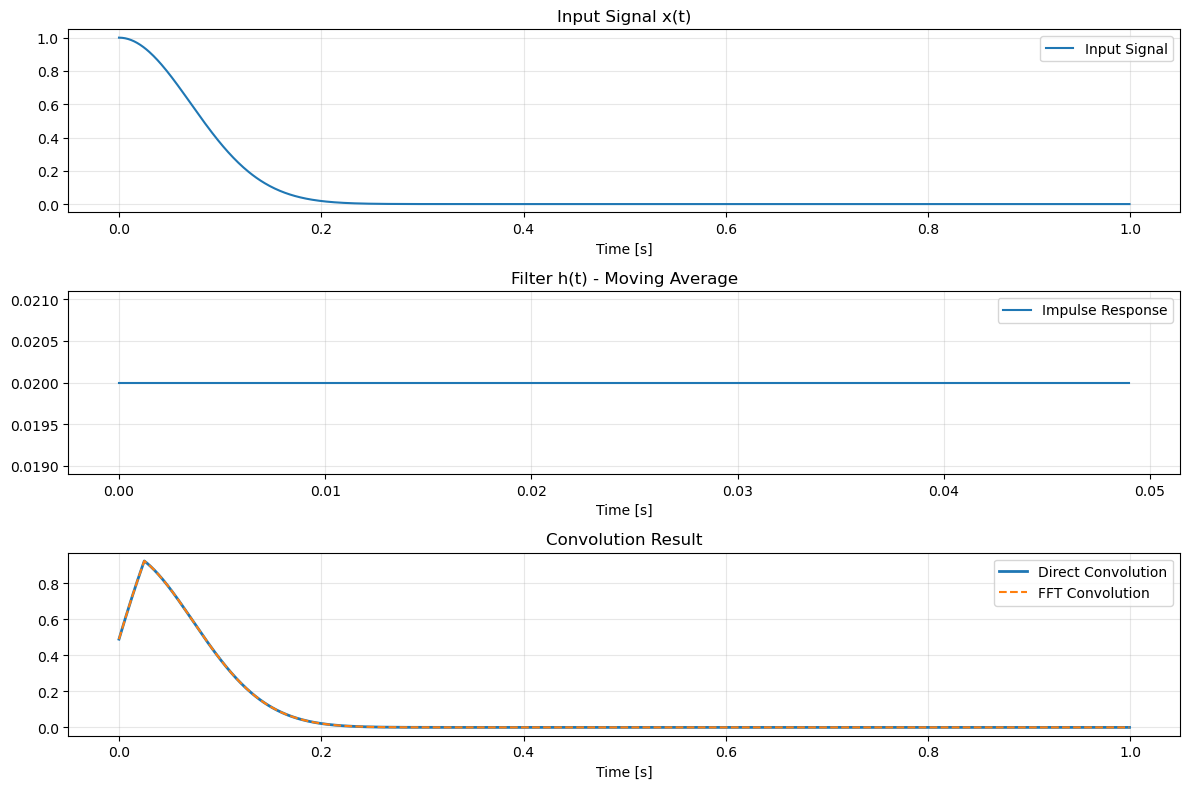

Mean Squared Error between methods: 1.90e-32


In [55]:
from scipy.signal import convolve

# Create signals
t_conv = np.linspace(0, 1, 1000, endpoint=False)
x = np.exp(-t_conv**2 / 0.01)  # Gaussian pulse
h = np.ones(50) / 50           # Moving average filter (boxcar)

# Method 1: Direct convolution
y_direct = convolve(x, h, mode='same')

# Method 2: FFT-based convolution (zero-pad to avoid circular convolution)
N_conv = len(x) + len(h) - 1
X = fft(x, n=N_conv)
H = fft(h, n=N_conv)
Y = X * H
y_fft = np.real(ifft(Y))
# Extract the 'same' region
start = (len(h) - 1) // 2
y_fft_same = y_fft[start:start + len(x)]

# Plot
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(t_conv, x, label='Input Signal')
axes[0].set_title('Input Signal x(t)')
axes[0].set_xlabel('Time [s]')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_conv[:len(h)], h, label='Impulse Response')
axes[1].set_title('Filter h(t) - Moving Average')
axes[1].set_xlabel('Time [s]')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_conv, y_direct, label='Direct Convolution', linewidth=2)
axes[2].plot(t_conv, y_fft_same, '--', label='FFT Convolution', linewidth=1.5)
axes[2].set_title('Convolution Result')
axes[2].set_xlabel('Time [s]')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Verify they are essentially identical
mse = np.mean((y_direct - y_fft_same) ** 2)
print(f"Mean Squared Error between methods: {mse:.2e}")


## 9. Example: Phase Information

The FFT returns complex numbers. The magnitude tells us "how much" of each frequency is present, but the **phase** tells us "when" those components align. Phase is crucial for signal reconstruction.


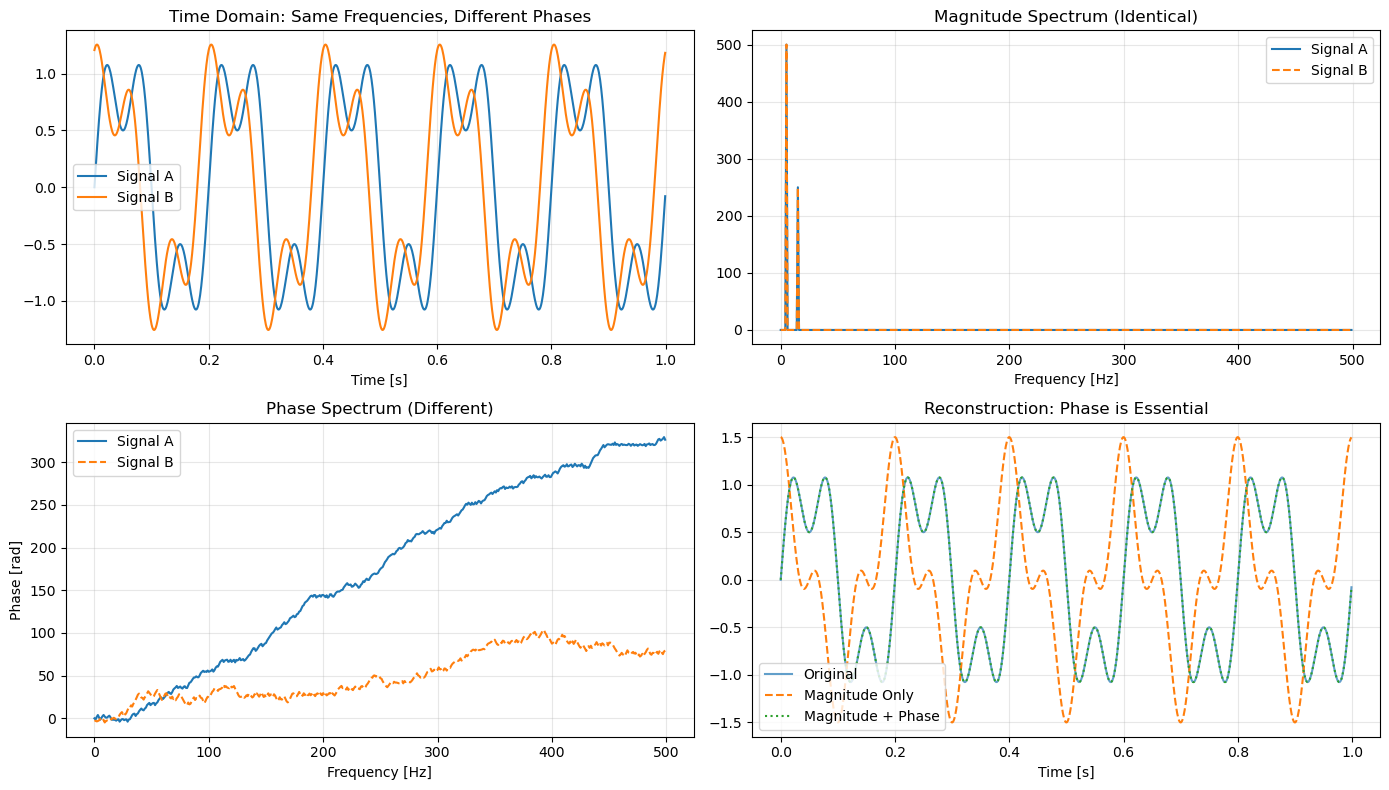

In [56]:
# Create two signals with same frequency content but different phases
t_phase = np.linspace(0, 1, 1000, endpoint=False)
f1, f2 = 5, 15

# Signal A: zero phase
sig_a = np.sin(2 * np.pi * f1 * t_phase) + 0.5 * np.sin(2 * np.pi * f2 * t_phase)

# Signal B: different phases
sig_b = np.sin(2 * np.pi * f1 * t_phase + np.pi/4) + 0.5 * np.sin(2 * np.pi * f2 * t_phase + np.pi/2)

# FFT
yf_a = fft(sig_a)
yf_b = fft(sig_b)
xf_phase = fftfreq(len(t_phase), 1/1000)

# Phase (unwrap for cleaner display)
phase_a = np.unwrap(np.angle(yf_a))
phase_b = np.unwrap(np.angle(yf_b))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Time domain
axes[0, 0].plot(t_phase, sig_a, label='Signal A')
axes[0, 0].plot(t_phase, sig_b, label='Signal B')
axes[0, 0].set_title('Time Domain: Same Frequencies, Different Phases')
axes[0, 0].set_xlabel('Time [s]')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Magnitude spectrum (should be identical)
axes[0, 1].plot(xf_phase[:500], np.abs(yf_a)[:500], label='Signal A')
axes[0, 1].plot(xf_phase[:500], np.abs(yf_b)[:500], '--', label='Signal B')
axes[0, 1].set_title('Magnitude Spectrum (Identical)')
axes[0, 1].set_xlabel('Frequency [Hz]')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Phase spectrum
axes[1, 0].plot(xf_phase[:500], phase_a[:500], label='Signal A')
axes[1, 0].plot(xf_phase[:500], phase_b[:500], '--', label='Signal B')
axes[1, 0].set_title('Phase Spectrum (Different)')
axes[1, 0].set_xlabel('Frequency [Hz]')
axes[1, 0].set_ylabel('Phase [rad]')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Reconstruction from magnitude only vs magnitude+phase
mag_only = np.abs(yf_a)
recon_mag_only = np.real(ifft(mag_only))
recon_full = np.real(ifft(yf_a))

axes[1, 1].plot(t_phase, sig_a, label='Original', alpha=0.7)
axes[1, 1].plot(t_phase, recon_mag_only, '--', label='Magnitude Only')
axes[1, 1].plot(t_phase, recon_full, ':', label='Magnitude + Phase')
axes[1, 1].set_title('Reconstruction: Phase is Essential')
axes[1, 1].set_xlabel('Time [s]')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Example: Power Spectral Density (PSD)

The **Power Spectral Density** describes how the power of a signal is distributed across frequencies. For real signals, we typically use:

$$PSD = \frac{|X[k]|^2}{N \cdot f_s}$$

We compare a deterministic signal with random (white) noise.


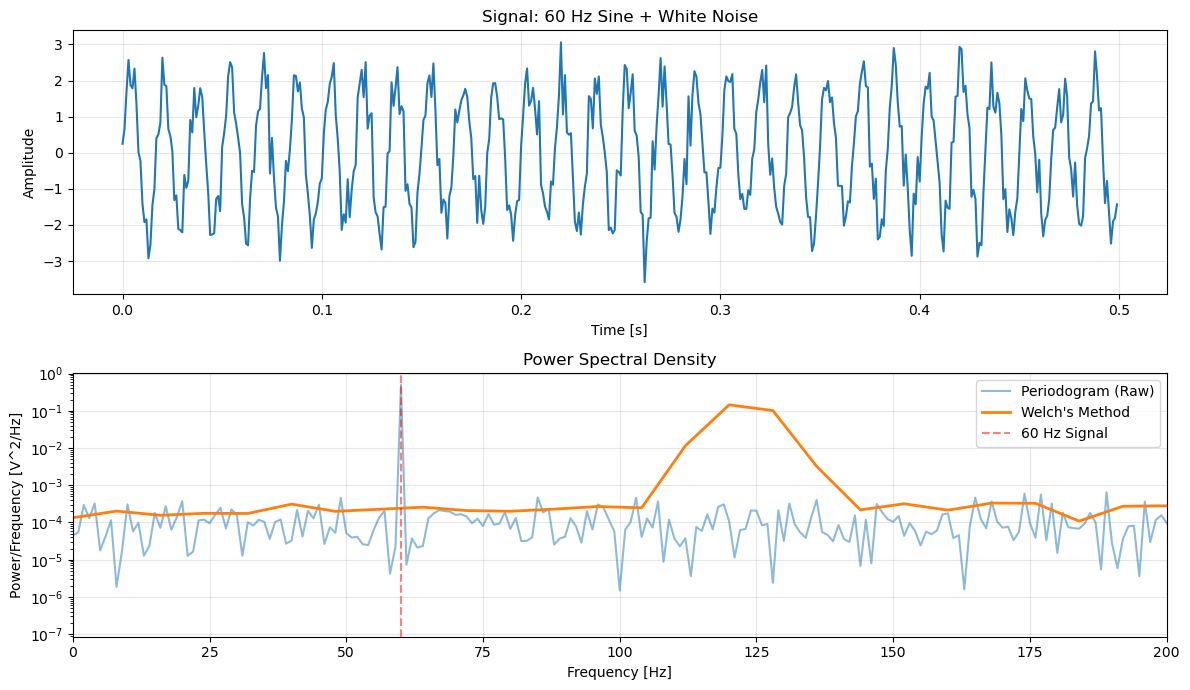

In [57]:
# White noise
np.random.seed(42)
noise = np.random.randn(len(t))

# Combine with a known signal
f_peak = 60
signal_psd = 2 * np.sin(2 * np.pi * f_peak * t) + 0.5 * noise

# Compute PSD using periodogram approach
N_psd = len(signal_psd)
yf_psd = fft(signal_psd)
psd = (np.abs(yf_psd) ** 2) / (N_psd * fs)
psd_single = psd[:N_psd//2]
xf_psd = xf[:N_psd//2]

# Also compute using Welch's method for smoother estimate
from scipy.signal import welch
f_welch, psd_welch = welch(signal_psd, fs=fs, nperseg=256)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Time domain
axes[0].plot(t[:500], signal_psd[:500])
axes[0].set_title('Signal: 60 Hz Sine + White Noise')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

# PSD comparison
axes[1].semilogy(xf_psd, psd_single, alpha=0.5, label='Periodogram (Raw)')
axes[1].semilogy(f_welch, psd_welch, linewidth=2, label="Welch's Method")
axes[1].axvline(f_peak, color='r', linestyle='--', alpha=0.5, label=f'{f_peak} Hz Signal')
axes[1].set_title('Power Spectral Density')
axes[1].set_xlabel('Frequency [Hz]')
axes[1].set_ylabel('Power/Frequency [V^2/Hz]')
axes[1].set_xlim(0, 200)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Summary

| Concept | Key Takeaway |
|---------|-------------|
| **FFT** | Efficient algorithm for computing DFT in $O(N \log N)$ |
| **Frequency Resolution** | $\Delta f = f_s / N$ — more samples = finer resolution |
| **Nyquist** | Sample at least 2x the highest frequency |
| **Leakage** | Use windowing when frequencies don't align with bins |
| **Gibbs** | Discontinuities cause ringing; need infinite harmonics |
| **Filtering** | Multiply in frequency domain, transform back |
| **STFT** | Time-frequency analysis for non-stationary signals |
| **Phase** | Essential for signal reconstruction and timing |
| **PSD** | Describes power distribution across frequencies |

The Fourier Transform is the bridge between the time domain and frequency domain — mastering it is fundamental to modern signal processing.
